In [1]:
from scripts.csv_continue_to_ds_discreet import csv_continue_to_ds_discreet
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score # GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import StratifiedKFold
from scripts.evaluate_model import evaluate_predictions
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, balanced_accuracy_score, matthews_corrcoef

import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt


c:\Users\David\Desktop\studio\data_analisys\kaggle\studio_data_science\000-in-evidenza\02-stroke\.venv-stroke\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X, y = csv_continue_to_ds_discreet()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0, stratify=y)

In [4]:
ratio = sum(y_train == 0) / sum(y_train == 1)

xgb = XGBClassifier(random_state=0, scale_pos_weight=ratio)

In [5]:
def specificity_score(y_true, y_pred):
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

In [6]:
scoring_metrics = {
    'roc_auc': 'roc_auc',
    'recall_classe0': make_scorer(recall_score, pos_label=0),
    'recall_classe1': make_scorer(recall_score, pos_label=1),
    'precision_classe0': make_scorer(precision_score, pos_label=0),
    'precision_classe1': make_scorer(precision_score, pos_label=1),
    'f1_classe0': make_scorer(f1_score, pos_label=0),
    'f1_classe1': make_scorer(f1_score, pos_label=1),
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
    'mattew_corrcoeff': make_scorer(matthews_corrcoef),
    'specificity': make_scorer(specificity_score),
}

In [7]:
params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.02, 0.1, 0.2], # 0.05,
    'max_depth': [2, 3, 4],
    'gamma': [0, 0.1, 0.3], # 0.5
    'min_child_weight': [1, 5, 10],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.2, 0.5, 1], #  0.7,
    'reg_lambda': [0, 0.2, 0.5, 1], #  0.7
}

cv_stratified = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

gs = RandomizedSearchCV(xgb, param_distributions=params, cv=cv_stratified, scoring=scoring_metrics, refit='roc_auc', n_jobs=-1, random_state=0, verbose=1, n_iter=500)


In [8]:
gs.fit(X_train, y_train)

Fitting 10 folds for each of 500 candidates, totalling 5000 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.02, ...], 'max_depth': [2, 3, ...], ...}"
,n_iter,500
,scoring,"{'balanced_accuracy': make_scorer(b...hod='predict'), 'f1_classe0': make_scorer(f..., pos_label=0), 'f1_classe1': make_scorer(f..., pos_label=1), 'mattew_corrcoeff': make_scorer(m...hod='predict'), ...}"
,n_jobs,-1
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,0
,error_score,nan


In [9]:
(f'best_score: {gs.best_score_}; best_params: {gs.best_params_}')

"best_score: 0.8202288955372167; best_params: {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alpha': 1, 'n_estimators': 50, 'min_child_weight': 5, 'max_depth': 2, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}"

In [10]:
results = pd.DataFrame(gs.cv_results_)

In [11]:
best_params = {}

In [12]:
for metric in scoring_metrics.keys():
    # print(f"Ricerca parametri per la metrica: {metric}")
    best_params[metric] = results.loc[results[f'mean_test_{metric}'].idxmax()]['params']
    # print(metric)
    # print(best_params[metric])

In [13]:
def evaluate_on_train_test_ensemble(models, X_train, y_train, X_test, y_test, threshold=0.5):
    print ("Evaluating on training set")
    train_pred = models.predict(X_train)
    train_proba = models.predict_proba(X_train)[:, 1]
    evaluate_predictions(train_pred, y_train, train_proba, model_name="Ensemble Training Set")
    
    print("Evaluating on test set")
    test_pred = models.predict(X_test)
    test_proba = models.predict_proba(X_test)[:, 1]
    evaluate_predictions(test_pred, y_test, test_proba, model_name="Ensemble Test Set")


recall classe 1: 8–12 (se è priorità primaria)
precision classe 1: 4–8 (vuoi anche limitare FP)
recall classe 0: 3–6 (non ignorarla del tutto)
precision classe 0: 0–1 (di solito inutile se è ~0.99)

In [62]:
def max_class_1(y_true, y_pred):
  recall_0_weight = 6
  precision_0_weight = 0.5
  recall_1_weight = 10
  precision_1_weight = 12
  return recall_score(y_true, y_pred, pos_label=0)*recall_0_weight + precision_score(y_true, y_pred, pos_label=0)*precision_0_weight + recall_score(y_true, y_pred, pos_label=1)*recall_1_weight + precision_score(y_true, y_pred, pos_label=1)*precision_1_weight

In [63]:
def voting_classifier_final_auto(X_train, y_train, best_params, n_trials=30):
    def objective(trial):
        min_weight = 0
        max_weight = 20
        weights = [
            trial.suggest_float("w_roc_auc", min_weight, max_weight),
            trial.suggest_float("w_precision_0", min_weight, max_weight),
            trial.suggest_float("w_recall_0", min_weight, max_weight),
            trial.suggest_float("w_recall_1", min_weight, max_weight),
            trial.suggest_float("w_precision_1", min_weight, max_weight),
            trial.suggest_float("w_f1_0", min_weight, max_weight),
            trial.suggest_float("w_f1_1", min_weight, max_weight),
            trial.suggest_float("w_balanced_accuracy", min_weight, max_weight),
            trial.suggest_float("w_mcc", min_weight, max_weight),
            trial.suggest_float("w_specificity", min_weight, max_weight),
        ]
        
        estimators = [
            ('xgb_roc_auc', XGBClassifier(**best_params['roc_auc'], scale_pos_weight=ratio)),
            ('xgb_precision_0', XGBClassifier(**best_params['precision_classe0'], scale_pos_weight=ratio)),
            ('xgb_recall_0', XGBClassifier(**best_params['recall_classe0'], scale_pos_weight=ratio)),
            ('xgb_recall_1', XGBClassifier(**best_params['recall_classe1'], scale_pos_weight=ratio)),
            ('xgb_precision_1', XGBClassifier(**best_params['precision_classe1'], scale_pos_weight=ratio)),
            ('xgb_f1_0', XGBClassifier(**best_params['f1_classe0'], scale_pos_weight=ratio)),
            ('xgb_f1_1', XGBClassifier(**best_params['f1_classe1'], scale_pos_weight=ratio)),
            ('xgb_balanced_accuracy', XGBClassifier(**best_params['balanced_accuracy'], scale_pos_weight=ratio)),
            ('xgb_mattew_corrcoeff', XGBClassifier(**best_params['mattew_corrcoeff'], scale_pos_weight=ratio)),
            ('xgb_specificity', XGBClassifier(**best_params['specificity'], scale_pos_weight=ratio)),
        ]

        voting_clf = VotingClassifier(
            estimators=estimators,
            voting='soft',
            weights=weights
        )

        score = cross_val_score(voting_clf, X_train, y_train, cv=10, scoring=make_scorer(max_class_1))
        return score.mean()
    sampler = optuna.samplers.TPESampler(seed=0)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=n_trials)

    best_weights = [
        study.best_params['w_roc_auc'],
        study.best_params['w_precision_0'],
        study.best_params['w_recall_0'],
        study.best_params['w_recall_1'],
        study.best_params['w_precision_1'],
        study.best_params['w_f1_0'],
        study.best_params['w_f1_1'],
        study.best_params['w_balanced_accuracy'],
        study.best_params['w_mcc'],
        study.best_params['w_specificity'],
    ]
    
    estimators = [
        ('xgb_roc_auc', XGBClassifier(**best_params['roc_auc'], scale_pos_weight=ratio)),
        ('xgb_precision_0', XGBClassifier(**best_params['precision_classe0'], scale_pos_weight=ratio)),
        ('xgb_recall_0', XGBClassifier(**best_params['recall_classe0'], scale_pos_weight=ratio)),
        ('xgb_recall_1', XGBClassifier(**best_params['recall_classe1'], scale_pos_weight=ratio)),
        ('xgb_precision_1', XGBClassifier(**best_params['precision_classe1'], scale_pos_weight=ratio)),
        ('xgb_f1_0', XGBClassifier(**best_params['f1_classe0'], scale_pos_weight=ratio)),
        ('xgb_f1_1', XGBClassifier(**best_params['f1_classe1'], scale_pos_weight=ratio)),
        ('xgb_balanced_accuracy', XGBClassifier(**best_params['balanced_accuracy'], scale_pos_weight=ratio)),
        ('xgb_mattew_corrcoeff', XGBClassifier(**best_params['mattew_corrcoeff'], scale_pos_weight=ratio)),
        ('xgb_specificity', XGBClassifier(**best_params['specificity'], scale_pos_weight=ratio)),
    ]

    final_model = VotingClassifier(estimators=estimators, voting='soft', weights=best_weights)
    final_model.fit(X_train, y_train)
    
    return final_model, best_weights

In [64]:
best_model, best_weights = voting_classifier_final_auto(X_train, y_train, best_params, n_trials=40)

[I 2025-08-29 21:09:37,709] A new study created in memory with name: no-name-acbe9ca5-8bfb-41d6-a548-5dce4cfbcb83
[I 2025-08-29 21:09:42,711] Trial 0 finished with value: 12.463106795955005 and parameters: {'w_roc_auc': 10.976270078546495, 'w_precision_0': 14.30378732744839, 'w_recall_0': 12.055267521432878, 'w_recall_1': 10.897663659937937, 'w_precision_1': 8.473095986778095, 'w_f1_0': 12.917882261333123, 'w_f1_1': 8.75174422525385, 'w_balanced_accuracy': 17.835460015641594, 'w_mcc': 19.273255210020587, 'w_specificity': 7.6688303765155545}. Best is trial 0 with value: 12.463106795955005.
[I 2025-08-29 21:09:48,006] Trial 1 finished with value: 12.526269955507756 and parameters: {'w_roc_auc': 15.834500761653292, 'w_precision_0': 10.577898395058089, 'w_recall_0': 11.360891221878646, 'w_recall_1': 18.51193276585322, 'w_precision_1': 1.4207211639577388, 'w_f1_0': 1.7425859940308142, 'w_f1_1': 0.4043679488065144, 'w_balanced_accuracy': 16.65239691095876, 'w_mcc': 15.56313501899701, 'w_spec

Evaluating on training set


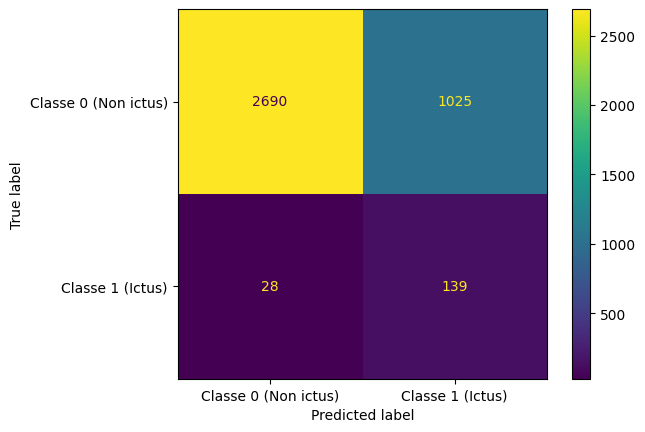

Percentuale di veri negativi: 72.41%
Percentuale di veri positivi: 83.23%
                      precision    recall  f1-score   support

Classe 0 (Non ictus)       0.99      0.72      0.84      3715
    Classe 1 (Ictus)       0.12      0.83      0.21       167

            accuracy                           0.73      3882
           macro avg       0.55      0.78      0.52      3882
        weighted avg       0.95      0.73      0.81      3882

[[2690 1025]
 [  28  139]]


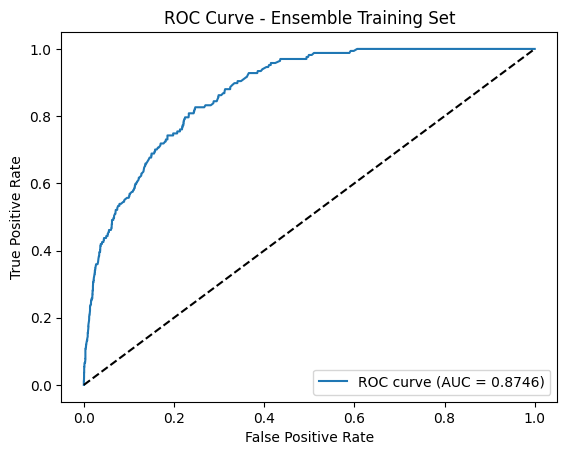

Evaluating on test set


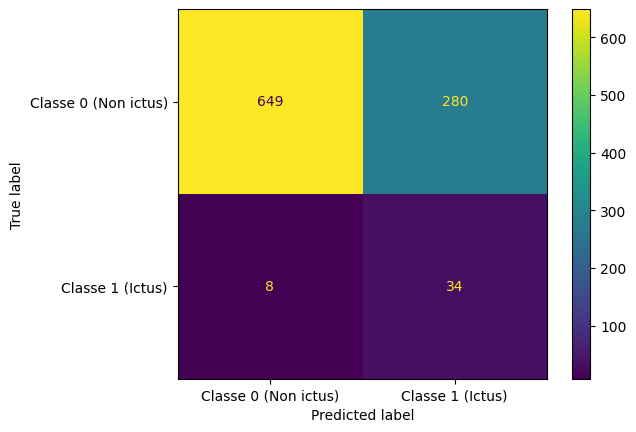

Percentuale di veri negativi: 69.86%
Percentuale di veri positivi: 80.95%
                      precision    recall  f1-score   support

Classe 0 (Non ictus)       0.99      0.70      0.82       929
    Classe 1 (Ictus)       0.11      0.81      0.19        42

            accuracy                           0.70       971
           macro avg       0.55      0.75      0.50       971
        weighted avg       0.95      0.70      0.79       971

[[649 280]
 [  8  34]]


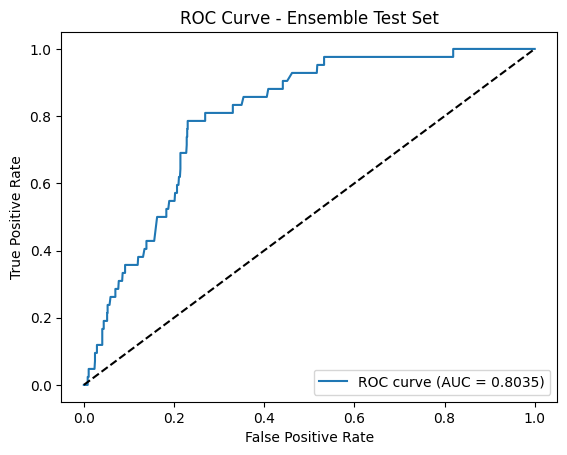

In [65]:
evaluate_on_train_test_ensemble(best_model, X_train, y_train, X_test, y_test)